# Run Independence — Are Your Seeds Actually IID?

Ictonyx's variance estimates assume the N runs in a variability study are independent and identically distributed. Identical distribution comes from using the same model, data, and hyperparameters on every run. Independence is harder — it assumes that run *i* tells you nothing about what happened in run *i-1*, beyond what their shared distribution already implies.

Independence can fail silently. GPU state leaking between runs, a training loop that reads from the same PRNG without re-seeding, filesystem caching of prior outputs, wall-clock-dependent batch shuffling — any of these can induce autocorrelation in the run-indexed metric series. The statistical tests that report confidence intervals on your mean accuracy assume IID; violations inflate your effective sample size and make those CIs too narrow.

This notebook shows what a clean independence diagnostic looks like, what a violation looks like, and how Ictonyx's `check_independence()` and `plot_run_independence_diagnostics()` let you tell them apart.

**Requirements:** `pip install ictonyx scikit-learn`

In [1]:
# !pip install ictonyx scikit-learn -q

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ictonyx as ix
from ictonyx import ArraysDataHandler
from ictonyx.analysis import check_independence, calculate_autocorr

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

print(f'Ictonyx {ix.__version__}')

Ictonyx 0.4.6


## The clean case — a real variability study

We start with a standard Ictonyx study: 30 runs of a RandomForest on breast cancer, with seeds spawned via `SeedSequence.spawn()`. This is the IID case by construction — each run's seed is an independent draw from the sequence, so the run-indexed accuracy series should show no autocorrelation at any lag.

In [4]:
data = load_breast_cancer()
X, y = data.data, data.target

results_clean = ix.variability_study(
    model=RandomForestClassifier,
    model_kwargs={'n_estimators': 50, 'max_depth': 8},
    data=(X, y),
    runs=30,
    seed=2026,
)

print(results_clean.summarize())

Loading and preparing data...
Array splits - Train: 398, Val: 57, Test: 114
Data loaded successfully

Starting Variability Study
  Runs: 30
  Epochs per run: 10
  Execution mode: in standard mode
  Seed: 2026



Variability Study:   0%|                                                             | 0/30 [00:00<?, ?run/s][Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
Variability Study:   3%|█                               | 1/30 [00:02<01:07,  2.32s/run, val_accuracy=0.9825][Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finis

--------------------------------------------------

Study Summary:
  Successful runs: 30/30
  train_accuracy: 1.0000 (SD = 0.0000)
  val_accuracy: 0.9825 (SD = 0.0046)
Variability Study Results
Successful runs: 30
Seed: 2026

Test Set Metrics:
--------------------
accuracy:
  N:                30
  Mean:             0.9643
  SD (sample, N-1): 0.0022
  SE:               0.0004
  Min:              0.9561
  Max:              0.9649
f1:
  N:                30
  Mean:             0.9717
  SD (sample, N-1): 0.0018
  SE:               0.0003
  Min:              0.9650
  Max:              0.9722
precision:
  N:                30
  Mean:             0.9589
  SD (sample, N-1): 0.0001
  SE:               0.0000
  Min:              0.9583
  Max:              0.9589
recall:
  N:                30
  Mean:             0.9850
  SD (sample, N-1): 0.0036
  SE:               0.0007
  Min:              0.9718
  Max:              0.9859

Validation Metrics:
--------------------
train_accuracy:
  N:        

## The diagnostic

`plot_run_independence_diagnostics()` computes the autocorrelation of the run-indexed final-accuracy series at lags 1 through `max_lag` and plots each with a Bonferroni-adjusted significance threshold. Runs that exceed the threshold are flagged; runs that don't appear in the expected-for-IID color.

The Bonferroni correction is important: testing 5 lags simultaneously at α=0.05 without correction gives a familywise false-positive rate of ~22.6% on genuinely independent data. The correction enforces the nominal α.

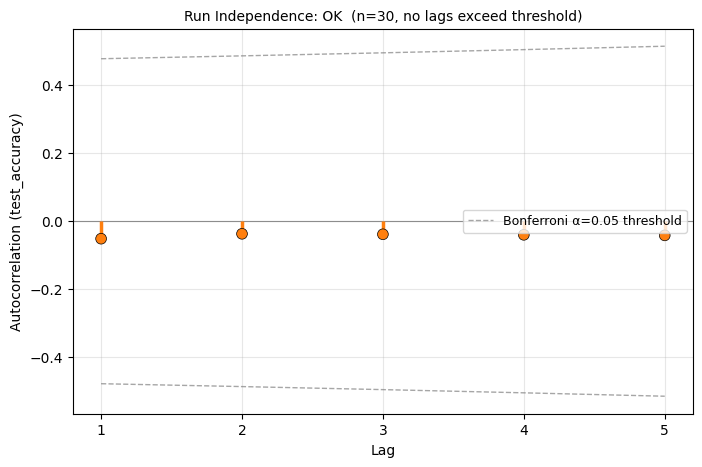

In [5]:
ix.plot_run_independence_diagnostics(
    results_clean,
    metric='test_accuracy',
    max_lag=5,
    show=False,
);

If the plot title reads `OK`, no lags exceed the threshold. Ictonyx's seed-spawning machinery did its job, and the variance estimates on this study are trustworthy.

We can also inspect the diagnostic numerically — this is what the plot is visualizing.

In [6]:
values = results_clean.get_test_metric_values('accuracy')
series = pd.Series(values)

is_independent, details = check_independence(series, max_lag=5, alpha=0.05)

print(f'Independent: {is_independent}')
print(f'N: {details["n"]}')
print(f'Significant lags: {details["significant_lags"] or "none"}')
print()
print('Per-lag autocorrelation:')
for lag, acf in details['autocorrelations'].items():
    threshold = details['thresholds'][lag]
    flag = '  *' if abs(acf) > threshold else ''
    print(f'  {lag}: {acf:+.4f}  (|threshold| = {threshold:.4f}){flag}')

Independent: True
N: 30
Significant lags: none

Per-lag autocorrelation:
  lag_1: -0.0514  (|threshold| = 0.4783)
  lag_2: -0.0370  (|threshold| = 0.4868)
  lag_3: -0.0385  (|threshold| = 0.4957)
  lag_4: -0.0400  (|threshold| = 0.5052)
  lag_5: -0.0417  (|threshold| = 0.5152)


## What a violation would look like

To show what the diagnostic catches, we construct a series that deliberately violates independence: an AR(1) process where each observation depends on the previous one. This simulates what a metric series might look like if, for example, GPU state or cached data were leaking between runs.

An AR(1) process is defined by `y_t = φ * y_{t-1} + ε_t` where `φ` is the autocorrelation coefficient and `ε_t` is white noise. At `φ = 0`, observations are independent. At `φ = 0.7`, there's strong positive autocorrelation — high values tend to follow high values, low values follow low values.

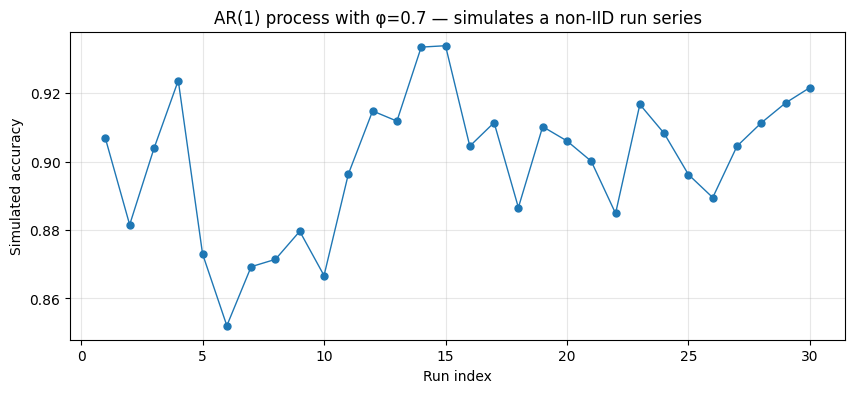

In [7]:
rng = np.random.default_rng(42)

# AR(1) with phi=0.7 — strong positive autocorrelation
phi = 0.7
n = 30
ar1 = np.zeros(n)
ar1[0] = rng.standard_normal()
for t in range(1, n):
    ar1[t] = phi * ar1[t-1] + rng.standard_normal()

# Rescale to look like an accuracy series in [0.85, 0.95]
ar1_series = 0.90 + 0.02 * ar1 / np.std(ar1)

plt.figure(figsize=(10, 4))
plt.plot(range(1, n+1), ar1_series, marker='o', linewidth=1, markersize=5)
plt.xlabel('Run index')
plt.ylabel('Simulated accuracy')
plt.title(f'AR(1) process with φ={phi} — simulates a non-IID run series')
plt.grid(True, alpha=0.3)
plt.show()

Eyeballing the plot, you can see the autocorrelation — runs that are close in index are also close in value, more than chance would dictate. The independence diagnostic formalizes this observation.

In [8]:
is_independent_ar1, details_ar1 = check_independence(
    pd.Series(ar1_series), max_lag=5, alpha=0.05
)

print(f'Independent: {is_independent_ar1}')
print(f'Significant lags: {details_ar1["significant_lags"]}')
print()
print('Per-lag autocorrelation:')
for lag, acf in details_ar1['autocorrelations'].items():
    threshold = details_ar1['thresholds'][lag]
    flag = '  * FLAGGED' if abs(acf) > threshold else ''
    print(f'  {lag}: {acf:+.4f}  (|threshold| = {threshold:.4f}){flag}')

Independent: False
Significant lags: [1]

Per-lag autocorrelation:
  lag_1: +0.5419  (|threshold| = 0.4783)  * FLAGGED
  lag_2: +0.2542  (|threshold| = 0.4868)
  lag_3: +0.1888  (|threshold| = 0.4957)
  lag_4: +0.0708  (|threshold| = 0.5052)
  lag_5: -0.1418  (|threshold| = 0.5152)


## Plotting the violation

`plot_run_independence_diagnostics()` accepts a `VariabilityStudyResults` in its normal path, so to plot this simulated series we'd need to wrap it in results-like form. Instead, we'll build the plot manually from the `check_independence` output — this also shows what the built-in plot is doing underneath.

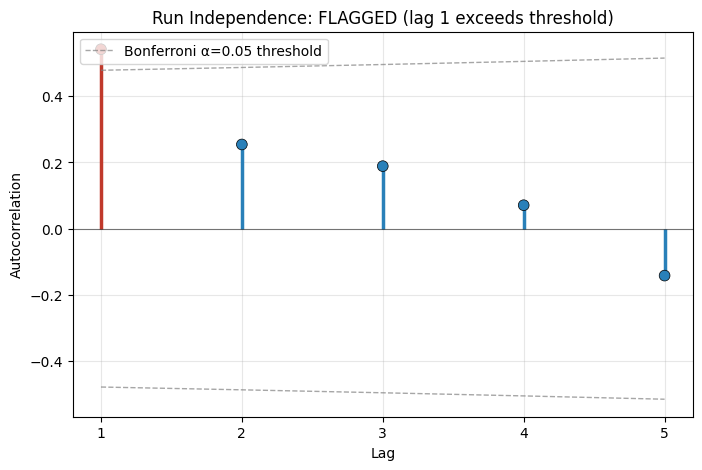

In [9]:
lags = sorted(int(k.split('_')[1]) for k in details_ar1['autocorrelations'])
acfs = [details_ar1['autocorrelations'][f'lag_{k}'] for k in lags]
thrs = [details_ar1['thresholds'][f'lag_{k}'] for k in lags]
sig_lags = set(details_ar1['significant_lags'])

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#c0392b' if lag in sig_lags else '#2980b9' for lag in lags]
ax.vlines(lags, 0, acfs, colors=colors, linewidth=2.5)
ax.scatter(lags, acfs, c=colors, s=60, zorder=3, edgecolor='black', linewidth=0.5)

ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.plot(lags, thrs, color='gray', linestyle='--', linewidth=1, alpha=0.7,
        label='Bonferroni α=0.05 threshold')
ax.plot(lags, [-t for t in thrs], color='gray', linestyle='--', linewidth=1, alpha=0.7)

ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.set_title(f'Run Independence: FLAGGED (lag {sorted(sig_lags)[0]} exceeds threshold)')
ax.set_xticks(lags)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

Lag 1 is flagged — the AR(1) autocorrelation is exactly what the diagnostic is designed to detect. A real Ictonyx user seeing this plot on an actual variability study should investigate: the seed-spawning isn't the likely culprit (Ictonyx uses `SeedSequence.spawn()` correctly), but something downstream of it may be. Candidates include shared GPU state, cached intermediate computations, or a training loop that re-seeds from wall-clock time rather than from the passed seed.

## Caveat: low power at small N

At the default `max_lag=5` with `N=30`, the diagnostic has reasonable power to detect strong autocorrelation. At `N=10`, which is typical for expensive studies, the power is much lower — the Bonferroni thresholds are wide, and mild violations can pass undetected. **Absence of a flagged lag is not strong evidence of independence at small N; it's absence of strong evidence of dependence.**

The `check_independence` output surfaces `N` directly, so you can calibrate your confidence:

In [10]:
# Run a small study for contrast
results_small = ix.variability_study(
    model=RandomForestClassifier,
    model_kwargs={'n_estimators': 20, 'max_depth': 5},
    data=(X, y),
    runs=10,
    seed=2026,
)

small_values = results_small.get_test_metric_values('accuracy')
_, details_small = check_independence(pd.Series(small_values), max_lag=5)

print(f'N=10 — threshold at lag 1: {details_small["thresholds"]["lag_1"]:.4f}')
print(f'N=30 — threshold at lag 1: {details["thresholds"]["lag_1"]:.4f}')
print()
print('The N=10 threshold is wider — the diagnostic is less sensitive at this size.')

Loading and preparing data...
Array splits - Train: 398, Val: 57, Test: 114
Data loaded successfully

Starting Variability Study
  Runs: 10
  Epochs per run: 10
  Execution mode: in standard mode
  Seed: 2026



Variability Study:   0%|                                                             | 0/10 [00:00<?, ?run/s][Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
Variability Study:  10%|███▏                            | 1/10 [00:02<00:18,  2.05s/run, val_accuracy=0.9825][Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finis

--------------------------------------------------

Study Summary:
  Successful runs: 10/10
  train_accuracy: 1.0000 (SD = 0.0000)
  val_accuracy: 0.9825 (SD = 0.0000)
N=10 — threshold at lag 1: 0.8586
N=30 — threshold at lag 1: 0.4783

The N=10 threshold is wider — the diagnostic is less sensitive at this size.


---

## Summary

Independence diagnostics aren't just a bureaucratic check; they're the bridge between what Ictonyx assumes about your runs (IID) and what might actually be true. When the diagnostic passes, your standard errors mean what the statistics textbook says they mean. When it flags a lag, the most likely culprit is infrastructure rather than the library — Ictonyx's seed-spawning is correct, but the downstream training pipeline can still introduce dependencies.

For any variability study you intend to publish or make consequential decisions from, run the independence diagnostic. It takes one function call and costs nothing beyond the study you already ran.